In [1]:
import time
import random
import numpy as np
from scipy.special import erf
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import sys
sys.path.insert(0, '/home/ferjao_k/sw/aare/build')
from aare import fit_scurve, fit_scurve_minuit_grad

In [2]:
import aare
aare.__file__

'/home/ferjao_k/sw/aare/build/aare/__init__.py'

In [14]:
ROWS = 100
COLS = 100
N_SCAN = 100
NOISE_FRAC = 0.05 # fraction of step height (p4)
SEED = 42
N_THREADS = 4

N_REPEATS = 10
N_WARMUP  = 3    # untimed iterations (icache + branch predictor warmup)
COOLDOWN  = 2.0  # seconds between (method, thread_count) pairs

## Synthetic data genrator

In [7]:
# Model in use
def scurve(x, p0, p1, p2, p3, p4, p5): # rising Scurve
    z = (x - p2) / (np.sqrt(2) * p3)
    return (p0 + p1 * x) + 0.5 * (1 + erf(z)) * (p4 + p5 * (x - p2))
    
def generate_3d_scurve_data(rows, cols, n_scan, noise_frac, seed):
    """
    Synthetic detector image stack with per-pixel rising S-curves.
 
    Returns
    -------
    x       : (n_scan,)
    y       : (rows, cols, n_scan)
    y_err   : (rows, cols, n_scan)
    truths  : dict  {name: (rows, cols) array}
    """
    rng = np.random.default_rng(seed)
 
    # Per-pixel ground truth - shapes (rows, cols)
    p0_true = rng.uniform(-5, 5, (rows, cols))          # baseline offset
    p1_true = rng.uniform(-0.02, 0.02, (rows, cols))    # baseline slope
    p2_true = rng.uniform(30, 70, (rows, cols))          # threshold
    p3_true = rng.uniform(2, 8, (rows, cols))            # width
    p4_true = rng.uniform(200, 800, (rows, cols))        # step height
    p5_true = rng.uniform(-0.5, 0.5, (rows, cols))      # post-step slope
 
    x = np.linspace(0, 100, n_scan)
 
    # broadcast: x -> (1, 1, n_scan),  params -> (rows, cols, 1)
    y_clean = scurve(
        x[None, None, :],
        p0_true[:, :, None], p1_true[:, :, None],
        p2_true[:, :, None], p3_true[:, :, None],
        p4_true[:, :, None], p5_true[:, :, None],
    )
 
    noise_sigma = noise_frac * p4_true[:, :, None] * np.ones_like(y_clean)
    y = y_clean + rng.normal(0, noise_sigma)
    y_err = noise_sigma.copy()
 
    truths = dict(p0=p0_true, p1=p1_true, p2=p2_true,
                  p3=p3_true, p4=p4_true, p5=p5_true)
    return x, y, y_err, truths    

In [8]:
def bench(fn, n_warmup=N_WARMUP, n_repeats=N_REPEATS):
    for _ in range(n_warmup):
        res = fn()
    times = []
    for _ in range(n_repeats):
        t0 = time.perf_counter()
        res = fn()
        t1 = time.perf_counter()
        times.append(t1 - t0)
    return res, times

## Data generation

In [9]:
print(f"Generating synthetic data: {ROWS}x{COLS} pixels, "
      f"{N_SCAN} scan points, noise_frac={NOISE_FRAC}\n")

x, y, yerr, truths = generate_3d_scurve_data(
    ROWS, COLS, N_SCAN, NOISE_FRAC, SEED
)

Generating synthetic data: 100x100 pixels, 100 scan points, noise_frac=0.05



## Define the tested/benched methods

In [16]:
METHOD_DEFS = [
    ("lmfit (LM)",
     lambda nt: lambda: fit_scurve(x, y, n_threads=nt),
     "#FF9800", {"linewidth": 3.0, "linestyle": "-"}),

    # ("Minuit2 (FD)",
    #  lambda nt: lambda: fit_scurve_minuit(x, y, n_threads=nt),
    #  "#FF9800", {"linewidth": 2.0, "linestyle": "--"}),

    ("Minuit2 (analytic)",
     lambda nt: lambda: fit_scurve_minuit_grad(x, y, n_threads=nt),
     "#4CAF50", {"linewidth": 4.0, "linestyle": ":"}),
]

colors = {label: c for label, _, c, _ in METHOD_DEFS}
styles = {label: s for label, _, _, s in METHOD_DEFS}

## Single-call benchmard

In [12]:
PARAM_NAMES = ["p0", "p1", "p2", "p3", "p4", "p5"]
ndf = N_SCAN - len(PARAM_NAMES)
# NOTE: fit_scurve returns Ndf = n_scan - 2 in its dict, which looks wrong
# for a 6-parameter model.  We use our own ndf = n_scan - 6 everywhere.

def extract_result(label, res):
    if isinstance(res, dict):
        out = {"par": res["par"]}
        if "par_err" in res:
            out["par_err"] = res["par_err"]
        if "chi2" in res:
            out["chi2"] = res["chi2"]
        return out
    # fallback: raw array, assume shape (rows, cols, 6)
    return {"par": res}

methods = {}
for label, factory, _, _ in METHOD_DEFS:
    time.sleep(COOLDOWN)
    res, times = bench(factory(N_THREADS))
    entry = extract_result(label, res)
    entry["times"] = times
    methods[label] = entry

# ---- summary table ----
header = f"{'Method':24s}  {'time (ms)':>10s}"
for pn in PARAM_NAMES:
    header += f"  {'med|d' + pn + '|':>10s}"
print(header)
print("-" * (26 + 12 + 12 * len(PARAM_NAMES)))
 
for name, m in methods.items():
    par   = m["par"]
    med_t = np.median(m["times"]) * 1e3
 
    deltas = "  ".join(
        f"{np.median(np.abs(par[:, :, i] - truths[pn])):10.4f}"
        for i, pn in enumerate(PARAM_NAMES)
    )
    chi2_str = ""
    if "chi2" in m:
        chi2_str = f"  chi2/ndf={np.median(m['chi2'] / ndf):.4f}"
 
    print(f"[{name:22s}]  {med_t:8.2f} ms  {deltas}{chi2_str}")

Method                     time (ms)    med|dp0|    med|dp1|    med|dp2|    med|dp3|    med|dp4|    med|dp5|
--------------------------------------------------------------------------------------------------------------
[lmfit (LM)            ]   1069.37 ms      5.1584      0.2294      0.2217      0.2711     12.3779      0.3766
[Minuit2 (analytic)    ]    632.79 ms      4.7459      0.2176      0.2203      0.2548     11.3817      0.3577  chi2/ndf=619.6832


## Thread scaling

In [13]:
thread_counts = [1, 2, 4, 8]
 
thread_times  = {label: [] for label, _, _, _ in METHOD_DEFS}
ttimes_stddev = {label: [] for label, _, _, _ in METHOD_DEFS}
 
for nt in thread_counts:
    run_order = list(METHOD_DEFS)
    random.shuffle(run_order)
 
    for label, factory, _, _ in run_order:
        time.sleep(COOLDOWN)
        _, times = bench(factory(nt))
 
        med = np.median(times) * 1e3
        std = np.std(times)   * 1e3
        thread_times[label].append(med)
        ttimes_stddev[label].append(std)
 
        per_px     = med / (ROWS * COLS) * 1e3
        per_px_std = std / (ROWS * COLS) * 1e3
        print(f"  {label:22s}  n_threads={nt:2d}  "
              f"{med:8.2f} ± {std:6.2f} ms  "
              f"({per_px:.4f} ± {per_px_std:.4f} µs/pixel)")

  lmfit (LM)              n_threads= 1   4151.81 ±  56.39 ms  (415.1814 ± 5.6390 µs/pixel)
  Minuit2 (analytic)      n_threads= 1   2259.55 ±  61.18 ms  (225.9551 ± 6.1184 µs/pixel)
  Minuit2 (analytic)      n_threads= 2   1138.24 ±  17.45 ms  (113.8241 ± 1.7454 µs/pixel)
  lmfit (LM)              n_threads= 2   2086.19 ±  11.75 ms  (208.6194 ± 1.1747 µs/pixel)
  Minuit2 (analytic)      n_threads= 4    643.04 ±  56.80 ms  (64.3041 ± 5.6804 µs/pixel)
  lmfit (LM)              n_threads= 4   1177.07 ±  29.04 ms  (117.7073 ± 2.9043 µs/pixel)
  lmfit (LM)              n_threads= 8   1205.17 ±  61.37 ms  (120.5170 ± 6.1373 µs/pixel)
  Minuit2 (analytic)      n_threads= 8    645.64 ±  33.15 ms  (64.5642 ± 3.3153 µs/pixel)


## Visualization: Residuals & Performance

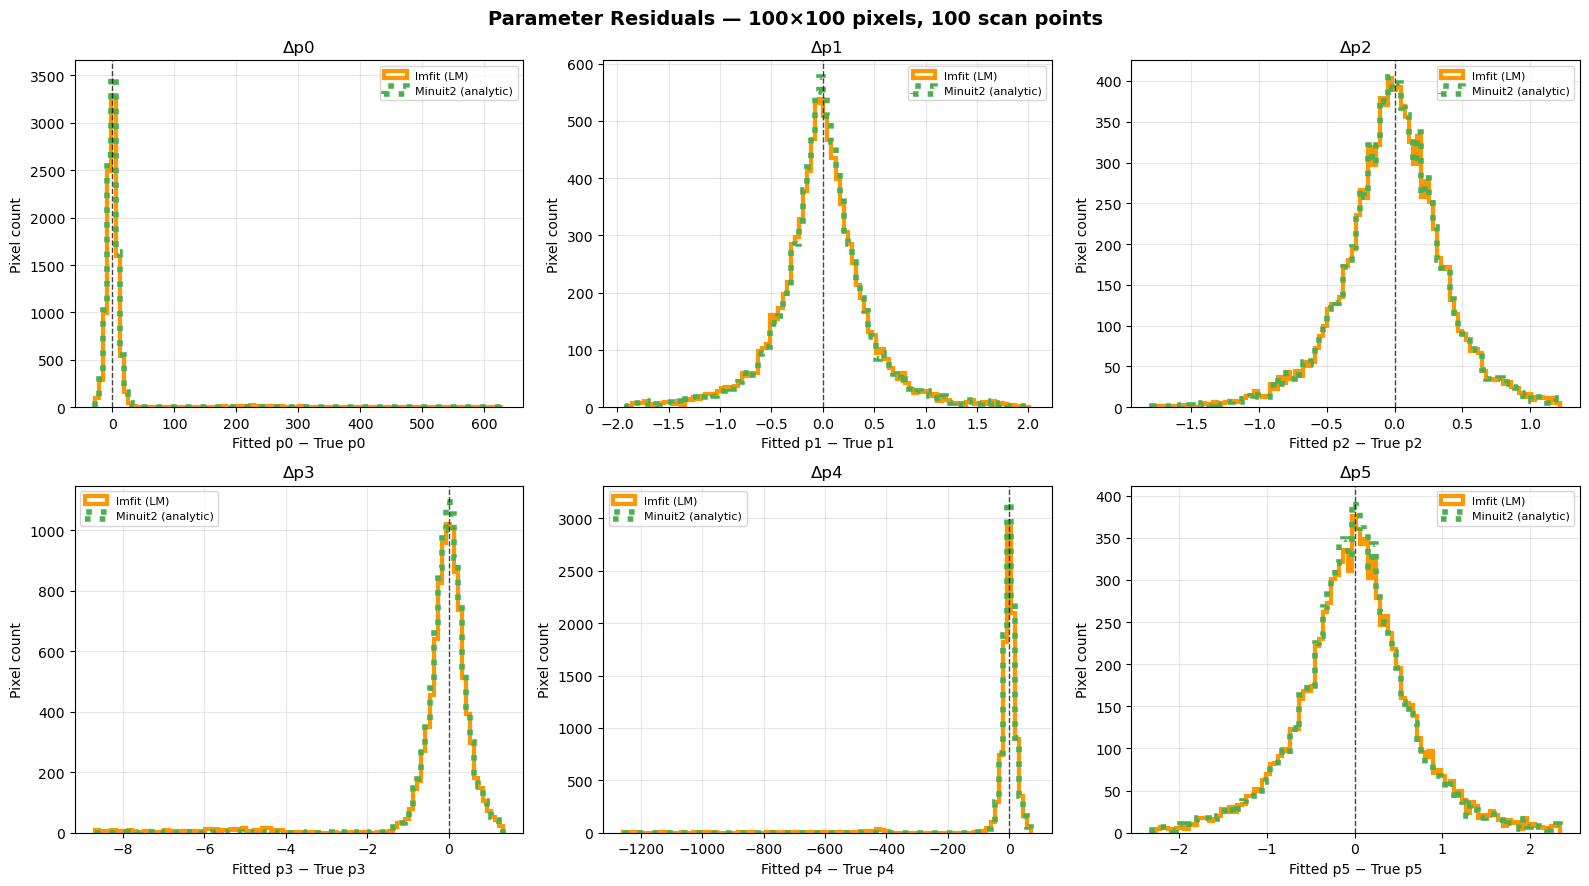

<Figure size 1400x500 with 0 Axes>

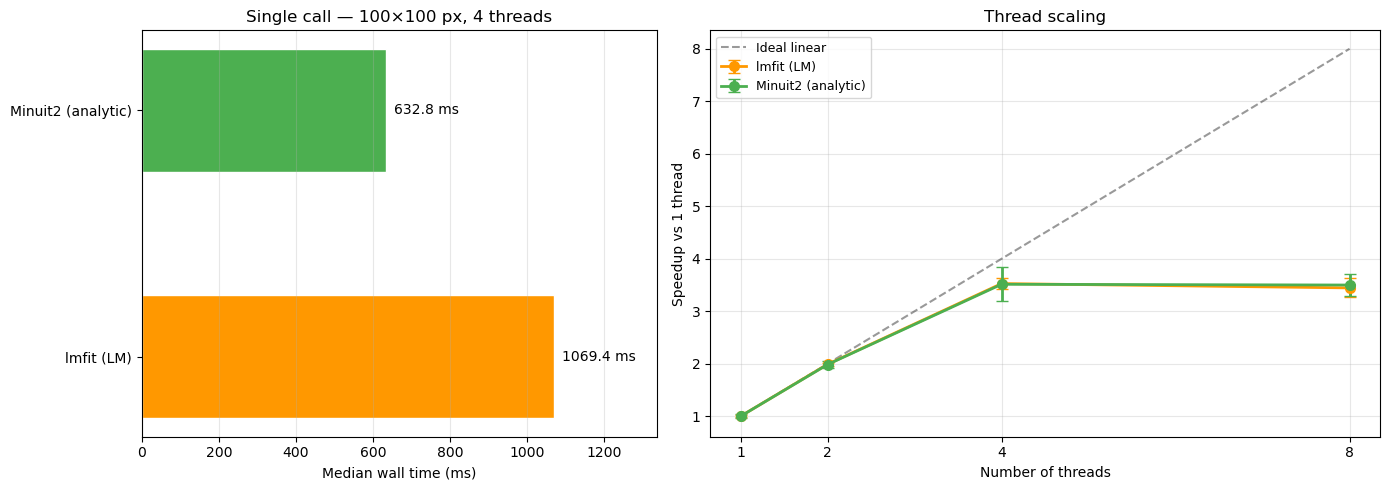

In [17]:
# FIGURE 1: Residual histograms (6 panels)
truth_arrays = [truths[pn] for pn in PARAM_NAMES]
 
fig1, axes1 = plt.subplots(2, 3, figsize=(16, 9))
fig1.suptitle(
    f"Parameter Residuals — {ROWS}×{COLS} pixels, {N_SCAN} scan points",
    fontsize=14, fontweight="bold")
 
for idx, (pname, truth) in enumerate(zip(PARAM_NAMES, truth_arrays)):
    ax = axes1.flat[idx]
 
    res_by_method = {}
    all_res = []
    for mname, m in methods.items():
        residual = (m["par"][:, :, idx] - truth).ravel()
        res_by_method[mname] = residual
        all_res.append(residual)
    all_res = np.concatenate(all_res)
 
    lo, hi = np.percentile(all_res, [0.5, 99.5])
    edges  = np.linspace(lo, hi, 101)
 
    for mname, r in res_by_method.items():
        ax.hist(r, bins=edges, histtype="step", label=mname,
                color=colors[mname],
                linewidth=styles[mname]["linewidth"],
                linestyle=styles[mname]["linestyle"])
 
    ax.axvline(0, color="k", linestyle="--", linewidth=1, alpha=0.7)
    ax.set_xlabel(f"Fitted {pname} − True {pname}")
    ax.set_ylabel("Pixel count")
    ax.set_title(f"Δ{pname}")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
 
fig1.tight_layout()

# FIGURE 2: bar chart + thread scaling
fig2 = plt.figure(figsize=(14, 5))
gs   = GridSpec(1, 2, figure=fig2, width_ratios=[1, 1.3])

# -- Left: bar chart at N_THREADS --
fig2 = plt.figure(figsize=(14, 5))
gs   = GridSpec(1, 2, figure=fig2, width_ratios=[1, 1.3])
 
ax2a    = fig2.add_subplot(gs[0])
names   = list(methods.keys())
medians = [np.median(methods[n]["times"]) * 1e3 for n in names]
bars    = ax2a.barh(names, medians,
                    color=[colors[n] for n in names],
                    edgecolor="white", height=0.5)
ax2a.set_xlabel("Median wall time (ms)")
ax2a.set_title(f"Single call — {ROWS}×{COLS} px, {N_THREADS} threads")
for bar, val in zip(bars, medians):
    ax2a.text(bar.get_width() + max(medians) * 0.02,
              bar.get_y() + bar.get_height() / 2,
              f"{val:.1f} ms", va="center", fontsize=10)
ax2a.grid(axis="x", alpha=0.3)
ax2a.set_xlim(0, max(medians) * 1.25)
 
ax2b = fig2.add_subplot(gs[1])
for label, _, _, _ in METHOD_DEFS:
    tt = thread_times[label]
    sd = ttimes_stddev[label]
    speedup     = [tt[0] / t for t in tt]
    speedup_err = [
        s * np.sqrt((sd[0] / tt[0])**2 + (sd[i] / tt[i])**2)
        for i, s in enumerate(speedup)
    ]
    ax2b.errorbar(thread_counts, speedup, yerr=speedup_err,
                  fmt="o-", label=label, color=colors[label],
                  linewidth=2, markersize=7, capsize=4)
 
ax2b.plot(thread_counts, thread_counts, "k--", alpha=0.4, label="Ideal linear")
ax2b.set_xlabel("Number of threads")
ax2b.set_ylabel("Speedup vs 1 thread")
ax2b.set_title("Thread scaling")
ax2b.set_xticks(thread_counts)
ax2b.legend(fontsize=9)
ax2b.grid(alpha=0.3)
 
fig2.tight_layout()
plt.show()